<a href="https://colab.research.google.com/github/chrishunt11/Basketball-Analytics/blob/main/NBA_Game_Prediction_Model_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data

In [1]:
from google.colab import files
import os

# Prompt to upload 'game.csv'
if not os.path.exists('game.csv'):
    print("Please upload 'game.csv' below:")
    uploaded = files.upload()
else:
    print("'game.csv' is already present in your workspace.")

Please upload 'game.csv' below:


Saving game.csv to game.csv


In [6]:
import pandas as pd
import numpy as np

# Load the original NBA game dataset
# game_id is used as the index because it uniquely identifies each game
df = pd.read_csv('game.csv', index_col='game_id')

# Reset the index
df = df.reset_index()

# Preview the dataset
df.head()


,game_id,season_id,team_id_home,team_abbreviation_home,team_name_home,game_date,matchup_home,wl_home,min,fgm_home,...,reb_away,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,plus_minus_away,video_available_away,season_type
0,24600001,21946,1610610035,HUS,Toronto Huskies,1946-11-01 00:00:00,HUS vs. NYK,L,0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,2,0,Regular Season
1,24600003,21946,1610610034,BOM,St. Louis Bombers,1946-11-02 00:00:00,BOM vs. PIT,W,0,20.0,...,NaN,NaN,NaN,NaN,NaN,25.0,51.0,-5,0,Regular Season
2,24600002,21946,1610610032,PRO,Providence Steamrollers,1946-11-02 00:00:00,PRO vs. BOS,W,0,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,53.0,-6,0,Regular Season
3,24600004,21946,1610610025,CHS,Chicago Stags,1946-11-02 00:00:00,CHS vs. NYK,W,0,21.0,...,NaN,NaN,NaN,NaN,NaN,22.0,47.0,-16,0,Regular Season
4,24600005,21946,1610610028,DEF,Detroit Falcons,1946-11-02 00:00:00,DEF vs. WAS,L,0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,50.0,17,0,Regular Season


## Cleaning

In [7]:
# Check the size, column types, and missing values before cleaning
print(df.shape)
df.info()

(65698, 55)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65698 entries, 0 to 65697
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   game_id                 65698 non-null  int64  
 1   season_id               65698 non-null  int64  
 2   team_id_home            65698 non-null  int64  
 3   team_abbreviation_home  65698 non-null  object 
 4   team_name_home          65698 non-null  object 
 5   game_date               65698 non-null  object 
 6   matchup_home            65698 non-null  object 
 7   wl_home                 65696 non-null  object 
 8   min                     65698 non-null  int64  
 9   fgm_home                65685 non-null  float64
 10  fga_home                50251 non-null  float64
 11  fg_pct_home             50208 non-null  float64
 12  fg3m_home               52480 non-null  float64
 13  fg3a_home               47015 non-null  float64
 14  fg3_pct_home            46

In [8]:
# Check for missing values in each column
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values.head(30)

,0
fg3_pct_home,19074
dreb_home,18999
dreb_away,18998
fg3_pct_away,18962
oreb_away,18936
oreb_home,18936
stl_home,18849
stl_away,18849
tov_away,18685
tov_home,18684


In [9]:
# Convert game_date to datetime so we can analyze missing data over time
df['game_date'] = pd.to_datetime(df['game_date'])

# Create a year column for data-quality checks
df['year'] = df['game_date'].dt.year

# Check missing values for key statistics by year
missing_by_year = df.groupby('year')[
    ['fg_pct_home', 'fg3_pct_home', 'reb_home', 'ast_home',
     'fg_pct_away', 'fg3_pct_away', 'reb_away', 'ast_away']
].apply(lambda x: x.isnull().sum())

missing_by_year.head(30)

,fg_pct_home,fg3_pct_home,reb_home,ast_home,fg_pct_away,fg3_pct_away,reb_away,ast_away
year,,,,,,,,
1946,118,128,128,128,118,128,128,128
1947,275,295,295,290,274,295,295,290
1948,276,289,289,288,276,289,289,288
1949,474,475,475,475,474,475,475,475
1950,505,509,509,509,505,509,509,509
1951,332,363,354,344,332,363,354,344
1952,322,365,360,359,322,365,360,359
1953,325,362,357,357,325,362,357,357
1954,283,323,314,314,283,323,314,314


In [10]:
# Calculate the percentage of missing values for key features by year
missing_pct_by_year = df.groupby('year')[
    ['fg_pct_home', 'fg3_pct_home', 'reb_home', 'ast_home',
     'fg_pct_away', 'fg3_pct_away', 'reb_away', 'ast_away']
].apply(lambda x: x.isnull().mean() * 100)

# Display more recent seasons
missing_pct_by_year.loc[1975:].round(1)

,fg_pct_home,fg3_pct_home,reb_home,ast_home,fg_pct_away,fg3_pct_away,reb_away,ast_away
year,,,,,,,,
1975,98.7,100.0,98.7,98.7,98.7,100.0,98.7,98.7
1976,86.3,100.0,86.3,86.3,86.3,100.0,86.3,86.3
1977,98.1,100.0,98.1,98.1,98.1,100.0,98.1,98.1
1978,99.1,100.0,99.1,99.1,99.1,100.0,99.1,99.1
1979,99.4,100.0,99.4,99.4,99.4,100.0,99.4,99.4
1980,99.2,99.5,99.2,99.2,99.2,99.3,99.2,99.2
1981,95.9,97.7,95.9,95.9,95.9,97.5,95.9,95.9
1982,48.0,88.8,46.7,47.7,48.0,88.4,46.7,47.5
1983,0.1,92.6,2.2,2.3,0.1,91.7,2.1,2.1


In [11]:
# Keep games from 1995 onward where key box-score data is consistently available
df = df[df['year'] >= 1995].copy()

# Sort games chronologically
df = df.sort_values(['game_date']).copy()

# Check the remaining dataset size
print(df.shape)

(36168, 56)


In [12]:
# Verify missing values after restricting the dataset
missing_after_filter = df.isnull().sum().sort_values(ascending=False)

missing_after_filter.head(20)

,0
wl_home,2
ft_pct_home,2
wl_away,2
fg3_pct_home,1
ft_pct_away,1
team_name_home,0
team_abbreviation_home,0
game_id,0
matchup_home,0
game_date,0


In [13]:
# Inspect rows that still contain missing values in potentially useful columns
columns_to_check = [
    'wl_home',
    'wl_away',
    'fg3_pct_home',
    'ft_pct_home',
    'ft_pct_away'
]

df[df[columns_to_check].isnull().any(axis=1)][
    ['game_date', 'team_name_home', 'team_name_away'] + columns_to_check
]

,game_date,team_name_home,team_name_away,wl_home,wl_away,fg3_pct_home,ft_pct_home,ft_pct_away
33642,1998-03-04,Philadelphia 76ers,Milwaukee Bucks,W,L,NaN,0.576,0.652
44984,2006-10-17,Cleveland Cavaliers,Tel Aviv Maccabi Elite,W,L,0.364,0.500,NaN
46430,2007-10-19,Boston Celtics,New Jersey Nets,NaN,NaN,0.375,0.750,0.722
47823,2008-10-11,Phoenix Suns,Denver Nuggets,NaN,NaN,0.125,0.690,0.474
65697,2023-02-19,Team LeBron,Team Giannis,L,W,0.283,NaN,0.750
65696,2023-02-19,Team LeBron,Team Giannis,L,W,0.283,NaN,0.750


In [14]:
# Inspect columns that may identify season or game type
[col for col in df.columns if
 'season' in col.lower()
 or 'game' in col.lower()]

['game_id', 'season_id', 'game_date', 'season_type']

In [15]:
# Look at the values in season_type, if that column exists
if 'season_type' in df.columns:
    print(df['season_type'].value_counts(dropna=False))

season_type
Regular Season    32555
Playoffs           2027
Pre Season         1536
All Star             26
All-Star             24
Name: count, dtype: int64


In [16]:
# Keep only regular-season and playoff games
# Preseason and All-Star games are excluded because they are not
# representative of normal competitive NBA games
df = df[df['season_type'].isin(['Regular Season', 'Playoffs'])].copy()

# Check the remaining game types
print(df['season_type'].value_counts())

# Check the new dataset size
print(df.shape)

season_type
Regular Season    32555
Playoffs           2027
Name: count, dtype: int64
(34582, 56)


In [17]:
# Recheck missing values after removing preseason and All-Star games
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values.head(10)

,0
fg3_pct_home,1
game_id,0
team_id_home,0
season_id,0
team_name_home,0
game_date,0
matchup_home,0
team_abbreviation_home,0
wl_home,0
min,0


In [18]:
# Inspect the remaining missing 3-point percentage
df[df['fg3_pct_home'].isnull()][
    ['game_date', 'team_name_home', 'team_name_away',
     'fg3m_home', 'fg3a_home', 'fg3_pct_home']
]

,game_date,team_name_home,team_name_away,fg3m_home,fg3a_home,fg3_pct_home
33642,1998-03-04,Philadelphia 76ers,Milwaukee Bucks,0.0,0.0,NaN


In [19]:
# Fill 3-point percentage with 0 when a team attempted zero 3-pointers
df.loc[
    (df['fg3a_home'] == 0) & (df['fg3_pct_home'].isnull()),
    'fg3_pct_home'
] = 0.0

In [20]:
# Confirm there are no remaining missing values
print(df.isnull().sum().sum())

0


In [21]:
# Check for duplicate game IDs
print("Duplicate game IDs:", df['game_id'].duplicated().sum())

# Check for completely duplicated rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate game IDs: 0
Duplicate rows: 0


In [22]:
# Verify that home and away results are valid and opposite
print(df['wl_home'].value_counts())
print(df['wl_away'].value_counts())

# Check for games where both teams have the same result
invalid_results = df[df['wl_home'] == df['wl_away']]

print("Games with invalid results:", len(invalid_results))

wl_home
W    20502
L    14080
Name: count, dtype: int64
wl_away
L    20502
W    14080
Name: count, dtype: int64
Games with invalid results: 0


In [23]:
# Verify that the recorded result agrees with the final score
score_mismatch = df[
    ((df['wl_home'] == 'W') & (df['pts_home'] <= df['pts_away'])) |
    ((df['wl_home'] == 'L') & (df['pts_home'] >= df['pts_away']))
]

print("Games where result and score disagree:", len(score_mismatch))

Games where result and score disagree: 0


## Feature Engineering

In [24]:
# Create one row for each home team's performance
home_games = df[[
    'game_id',
    'game_date',
    'team_name_home',
    'team_name_away',
    'wl_home',
    'pts_home',
    'fg_pct_home',
    'fg3_pct_home',
    'ft_pct_home',
    'reb_home',
    'ast_home',
    'tov_home'
]].copy()

# Rename columns so home and away games can later use the same structure
home_games = home_games.rename(columns={
    'team_name_home': 'team',
    'team_name_away': 'opponent',
    'wl_home': 'result',
    'pts_home': 'pts',
    'fg_pct_home': 'fg_pct',
    'fg3_pct_home': 'fg3_pct',
    'ft_pct_home': 'ft_pct',
    'reb_home': 'reb',
    'ast_home': 'ast',
    'tov_home': 'tov'
})

# Identify these observations as home games
home_games['is_home'] = 1

# Convert wins and losses to a numeric value for later rolling calculations
home_games['win'] = (home_games['result'] == 'W').astype(int)

home_games.head()

,game_id,game_date,team,opponent,result,pts,fg_pct,fg3_pct,ft_pct,reb,ast,tov,is_home,win
29530,29400371,1995-01-03,Dallas Mavericks,Houston Rockets,L,98.0,0.429,0.250,0.786,48.0,23.0,18.0,1,0
29531,29400373,1995-01-03,New Jersey Nets,Indiana Pacers,W,114.0,0.479,0.538,0.822,52.0,28.0,11.0,1,1
29532,29400377,1995-01-03,Washington Bullets,Seattle SuperSonics,L,107.0,0.553,0.267,0.826,25.0,21.0,23.0,1,0
29533,29400376,1995-01-03,Golden State Warriors,San Antonio Spurs,L,86.0,0.379,0.091,0.679,48.0,23.0,16.0,1,0
29534,29400375,1995-01-03,Atlanta Hawks,Portland Trail Blazers,L,98.0,0.444,0.286,0.667,42.0,23.0,12.0,1,0


In [25]:
# Create one row for each away team's performance
away_games = df[[
    'game_id',
    'game_date',
    'team_name_away',
    'team_name_home',
    'wl_away',
    'pts_away',
    'fg_pct_away',
    'fg3_pct_away',
    'ft_pct_away',
    'reb_away',
    'ast_away',
    'tov_away'
]].copy()

# Rename columns to match the home-team dataset
away_games = away_games.rename(columns={
    'team_name_away': 'team',
    'team_name_home': 'opponent',
    'wl_away': 'result',
    'pts_away': 'pts',
    'fg_pct_away': 'fg_pct',
    'fg3_pct_away': 'fg3_pct',
    'ft_pct_away': 'ft_pct',
    'reb_away': 'reb',
    'ast_away': 'ast',
    'tov_away': 'tov'
})

# Identify these observations as away games
away_games['is_home'] = 0

# Convert wins and losses to numeric values
away_games['win'] = (away_games['result'] == 'W').astype(int)

away_games.head()

,game_id,game_date,team,opponent,result,pts,fg_pct,fg3_pct,ft_pct,reb,ast,tov,is_home,win
29530,29400371,1995-01-03,Houston Rockets,Dallas Mavericks,W,110.0,0.566,0.692,0.938,32.0,20.0,18.0,0,1
29531,29400373,1995-01-03,Indiana Pacers,New Jersey Nets,L,103.0,0.432,0.421,0.864,38.0,22.0,12.0,0,0
29532,29400377,1995-01-03,Seattle SuperSonics,Washington Bullets,W,121.0,0.540,0.500,0.773,32.0,30.0,21.0,0,1
29533,29400376,1995-01-03,San Antonio Spurs,Golden State Warriors,W,91.0,0.455,0.308,0.700,43.0,30.0,13.0,0,1
29534,29400375,1995-01-03,Portland Trail Blazers,Atlanta Hawks,W,103.0,0.444,0.357,0.545,51.0,19.0,10.0,0,1


In [26]:
# Add raw shooting totals so rolling percentages can be
# calculated from makes and attempts instead of averaging percentages
shooting_cols_home = df[[
    'game_id',
    'fgm_home',
    'fga_home',
    'fg3m_home',
    'fg3a_home',
    'ftm_home',
    'fta_home'
]].copy()

shooting_cols_home = shooting_cols_home.rename(columns={
    'fgm_home': 'fgm',
    'fga_home': 'fga',
    'fg3m_home': 'fg3m',
    'fg3a_home': 'fg3a',
    'ftm_home': 'ftm',
    'fta_home': 'fta'
})

home_games = home_games.merge(
    shooting_cols_home,
    on='game_id',
    how='left'
)

In [27]:
shooting_cols_away = df[[
    'game_id',
    'fgm_away',
    'fga_away',
    'fg3m_away',
    'fg3a_away',
    'ftm_away',
    'fta_away'
]].copy()

shooting_cols_away = shooting_cols_away.rename(columns={
    'fgm_away': 'fgm',
    'fga_away': 'fga',
    'fg3m_away': 'fg3m',
    'fg3a_away': 'fg3a',
    'ftm_away': 'ftm',
    'fta_away': 'fta'
})

away_games = away_games.merge(
    shooting_cols_away,
    on='game_id',
    how='left'
)

In [28]:
print(home_games.columns.tolist())
print(away_games.columns.tolist())
print("Same columns:", home_games.columns.equals(away_games.columns))

['game_id', 'game_date', 'team', 'opponent', 'result', 'pts', 'fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'tov', 'is_home', 'win', 'fgm', 'fga', 'fg3m', 'fg3a', 'ftm', 'fta']
['game_id', 'game_date', 'team', 'opponent', 'result', 'pts', 'fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'tov', 'is_home', 'win', 'fgm', 'fga', 'fg3m', 'fg3a', 'ftm', 'fta']
Same columns: True


In [29]:
# Combine home and away performances into one team-game history table
team_games = pd.concat(
    [home_games, away_games],
    ignore_index=True
)

# Sort each team's games chronologically
team_games = team_games.sort_values(
    ['team', 'game_date', 'game_id']
).reset_index(drop=True)

print(team_games.shape)
team_games.head()

(69164, 20)


,game_id,game_date,team,opponent,result,pts,fg_pct,fg3_pct,ft_pct,reb,ast,tov,is_home,win,fgm,fga,fg3m,fg3a,ftm,fta
0,29400375,1995-01-03,Atlanta Hawks,Portland Trail Blazers,L,98.0,0.444,0.286,0.667,42.0,23.0,12.0,1,0,36.0,81.0,4.0,14.0,22.0,33.0
1,29400381,1995-01-04,Atlanta Hawks,New York Knicks,L,80.0,0.397,0.238,0.840,33.0,16.0,18.0,0,0,27.0,68.0,5.0,21.0,21.0,25.0
2,29400393,1995-01-06,Atlanta Hawks,Washington Bullets,W,112.0,0.482,0.571,0.645,43.0,27.0,11.0,1,1,40.0,83.0,12.0,21.0,20.0,31.0
3,29400407,1995-01-07,Atlanta Hawks,New Jersey Nets,W,102.0,0.457,0.500,0.455,47.0,26.0,9.0,1,1,42.0,92.0,8.0,16.0,10.0,22.0
4,29400422,1995-01-10,Atlanta Hawks,Washington Bullets,W,99.0,0.468,0.526,0.714,45.0,18.0,20.0,0,1,37.0,79.0,10.0,19.0,15.0,21.0


In [30]:
# Inspect one team's chronological game history
team_games[
    team_games['team'] == 'Philadelphia 76ers'
][
    ['game_date', 'team', 'opponent', 'is_home', 'result', 'pts']
].head(15)

,game_date,team,opponent,is_home,result,pts
48974,1995-01-04,Philadelphia 76ers,Phoenix Suns,0,L,122.0
48975,1995-01-05,Philadelphia 76ers,Los Angeles Clippers,0,L,93.0
48976,1995-01-07,Philadelphia 76ers,Utah Jazz,0,L,90.0
48977,1995-01-11,Philadelphia 76ers,Chicago Bulls,1,L,77.0
48978,1995-01-13,Philadelphia 76ers,New Jersey Nets,1,L,101.0
48979,1995-01-14,Philadelphia 76ers,Orlando Magic,0,L,70.0
48980,1995-01-16,Philadelphia 76ers,Detroit Pistons,1,L,110.0
48981,1995-01-18,Philadelphia 76ers,Atlanta Hawks,0,W,92.0
48982,1995-01-20,Philadelphia 76ers,Washington Bullets,0,L,98.0
48983,1995-01-21,Philadelphia 76ers,Los Angeles Lakers,1,W,117.0


In [31]:
# Create pre-game rolling features using ONLY previous games
# shift(1) prevents the current game's result/stats from entering its own features

team_games['win_pct_last_10'] = (
    team_games.groupby('team')['win']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=10).mean())
)

team_games['pts_avg_last_10'] = (
    team_games.groupby('team')['pts']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=10).mean())
)

In [32]:
# Inspect the Sixers' first 15 games and their pre-game rolling features
team_games[
    team_games['team'] == 'Philadelphia 76ers'
][
    ['game_date', 'opponent', 'result', 'pts',
     'win_pct_last_10', 'pts_avg_last_10']
].head(15)

,game_date,opponent,result,pts,win_pct_last_10,pts_avg_last_10
48974,1995-01-04,Phoenix Suns,L,122.0,NaN,NaN
48975,1995-01-05,Los Angeles Clippers,L,93.0,NaN,NaN
48976,1995-01-07,Utah Jazz,L,90.0,NaN,NaN
48977,1995-01-11,Chicago Bulls,L,77.0,NaN,NaN
48978,1995-01-13,New Jersey Nets,L,101.0,NaN,NaN
48979,1995-01-14,Orlando Magic,L,70.0,NaN,NaN
48980,1995-01-16,Detroit Pistons,L,110.0,NaN,NaN
48981,1995-01-18,Atlanta Hawks,W,92.0,NaN,NaN
48982,1995-01-20,Washington Bullets,L,98.0,NaN,NaN
48983,1995-01-21,Los Angeles Lakers,W,117.0,NaN,NaN


In [33]:
# Create rolling averages for additional team performance statistics
rolling_stats = ['reb', 'ast', 'tov']

for stat in rolling_stats:
    team_games[f'{stat}_avg_last_10'] = (
        team_games.groupby('team')[stat]
        .transform(lambda x: x.shift(1).rolling(10, min_periods=10).mean())
    )

In [34]:
# Calculate rolling shooting totals using only the previous 10 games
shooting_stats = ['fgm', 'fga', 'fg3m', 'fg3a', 'ftm', 'fta']

for stat in shooting_stats:
    team_games[f'{stat}_last_10'] = (
        team_games.groupby('team')[stat]
        .transform(lambda x: x.shift(1).rolling(10, min_periods=10).sum())
    )

# Calculate true shooting percentages across the previous 10 games
team_games['fg_pct_last_10'] = (
    team_games['fgm_last_10'] / team_games['fga_last_10']
)

team_games['fg3_pct_last_10'] = (
    team_games['fg3m_last_10'] / team_games['fg3a_last_10']
)

team_games['ft_pct_last_10'] = (
    team_games['ftm_last_10'] / team_games['fta_last_10']
)

In [35]:
team_games[
    team_games['team'] == 'Philadelphia 76ers'
][[
    'game_date',
    'opponent',
    'win_pct_last_10',
    'pts_avg_last_10',
    'fg_pct_last_10',
    'fg3_pct_last_10',
    'ft_pct_last_10',
    'reb_avg_last_10',
    'ast_avg_last_10',
    'tov_avg_last_10'
]].head(15)

,game_date,opponent,win_pct_last_10,pts_avg_last_10,fg_pct_last_10,fg3_pct_last_10,ft_pct_last_10,reb_avg_last_10,ast_avg_last_10,tov_avg_last_10
48974,1995-01-04,Phoenix Suns,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48975,1995-01-05,Los Angeles Clippers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48976,1995-01-07,Utah Jazz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48977,1995-01-11,Chicago Bulls,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48978,1995-01-13,New Jersey Nets,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48979,1995-01-14,Orlando Magic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48980,1995-01-16,Detroit Pistons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48981,1995-01-18,Atlanta Hawks,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48982,1995-01-20,Washington Bullets,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48983,1995-01-21,Los Angeles Lakers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# Add stable team IDs to the home and away history tables
home_team_ids = df[['game_id', 'team_id_home']].rename(
    columns={'team_id_home': 'team_id'}
)

away_team_ids = df[['game_id', 'team_id_away']].rename(
    columns={'team_id_away': 'team_id'}
)

home_games = home_games.merge(home_team_ids, on='game_id', how='left')
away_games = away_games.merge(away_team_ids, on='game_id', how='left')

In [37]:
# Rebuild team history using the stable team ID
team_games = pd.concat(
    [home_games, away_games],
    ignore_index=True
)

team_games = team_games.sort_values(
    ['team_id', 'game_date', 'game_id']
).reset_index(drop=True)

In [38]:
# Create pre-game rolling win percentage and points
team_games['win_pct_last_10'] = (
    team_games.groupby('team_id')['win']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=10).mean())
)

team_games['pts_avg_last_10'] = (
    team_games.groupby('team_id')['pts']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=10).mean())
)

# Rolling averages for counting statistics
for stat in ['reb', 'ast', 'tov']:
    team_games[f'{stat}_avg_last_10'] = (
        team_games.groupby('team_id')[stat]
        .transform(lambda x: x.shift(1).rolling(10, min_periods=10).mean())
    )

# Rolling shooting totals
for stat in ['fgm', 'fga', 'fg3m', 'fg3a', 'ftm', 'fta']:
    team_games[f'{stat}_last_10'] = (
        team_games.groupby('team_id')[stat]
        .transform(lambda x: x.shift(1).rolling(10, min_periods=10).sum())
    )

# Calculate shooting percentages from rolling makes and attempts
team_games['fg_pct_last_10'] = (
    team_games['fgm_last_10'] / team_games['fga_last_10']
)

team_games['fg3_pct_last_10'] = (
    team_games['fg3m_last_10'] / team_games['fg3a_last_10']
)

team_games['ft_pct_last_10'] = (
    team_games['ftm_last_10'] / team_games['fta_last_10']
)

In [39]:
team_games[
    team_games['team'] == 'Philadelphia 76ers'
][[
    'game_date',
    'team_id',
    'opponent',
    'win_pct_last_10',
    'pts_avg_last_10'
]].head(15)

,game_date,team_id,opponent,win_pct_last_10,pts_avg_last_10
41581,1995-01-04,1610612755,Phoenix Suns,NaN,NaN
41582,1995-01-05,1610612755,Los Angeles Clippers,NaN,NaN
41583,1995-01-07,1610612755,Utah Jazz,NaN,NaN
41584,1995-01-11,1610612755,Chicago Bulls,NaN,NaN
41585,1995-01-13,1610612755,New Jersey Nets,NaN,NaN
41586,1995-01-14,1610612755,Orlando Magic,NaN,NaN
41587,1995-01-16,1610612755,Detroit Pistons,NaN,NaN
41588,1995-01-18,1610612755,Atlanta Hawks,NaN,NaN
41589,1995-01-20,1610612755,Washington Bullets,NaN,NaN
41590,1995-01-21,1610612755,Los Angeles Lakers,NaN,NaN


In [41]:
# Select the pre-game features that will be used for each team
pregame_features = team_games[[
    'game_id',
    'team_id',
    'win_pct_last_10',
    'pts_avg_last_10',
    'fg_pct_last_10',
    'fg3_pct_last_10',
    'ft_pct_last_10',
    'reb_avg_last_10',
    'ast_avg_last_10',
    'tov_avg_last_10'
]].copy()

# Create home-team pre-game features
home_features = pregame_features.rename(columns={
    'team_id': 'team_id_home',
    'win_pct_last_10': 'home_win_pct_last_10',
    'pts_avg_last_10': 'home_pts_avg_last_10',
    'fg_pct_last_10': 'home_fg_pct_last_10',
    'fg3_pct_last_10': 'home_fg3_pct_last_10',
    'ft_pct_last_10': 'home_ft_pct_last_10',
    'reb_avg_last_10': 'home_reb_avg_last_10',
    'ast_avg_last_10': 'home_ast_avg_last_10',
    'tov_avg_last_10': 'home_tov_avg_last_10'
})

# Create away-team pre-game features
away_features = pregame_features.rename(columns={
    'team_id': 'team_id_away',
    'win_pct_last_10': 'away_win_pct_last_10',
    'pts_avg_last_10': 'away_pts_avg_last_10',
    'fg_pct_last_10': 'away_fg_pct_last_10',
    'fg3_pct_last_10': 'away_fg3_pct_last_10',
    'ft_pct_last_10': 'away_ft_pct_last_10',
    'reb_avg_last_10': 'away_reb_avg_last_10',
    'ast_avg_last_10': 'away_ast_avg_last_10',
    'tov_avg_last_10': 'away_tov_avg_last_10'
})

print("Home features:", home_features.shape)
print("Away features:", away_features.shape)

Home features: (69164, 10)
Away features: (69164, 10)


In [42]:
# Start with identifying information and the prediction target
model_df = df[[
    'game_id',
    'game_date',
    'season_type',
    'team_id_home',
    'team_name_home',
    'team_id_away',
    'team_name_away',
    'wl_home'
]].copy()

# Target: 1 = home team won, 0 = home team lost
model_df['home_win'] = (model_df['wl_home'] == 'W').astype(int)

# Attach the home team's pre-game history
model_df = model_df.merge(
    home_features,
    on=['game_id', 'team_id_home'],
    how='left'
)

# Attach the away team's pre-game history
model_df = model_df.merge(
    away_features,
    on=['game_id', 'team_id_away'],
    how='left'
)

print(model_df.shape)
model_df.head()

(34582, 25)


,game_id,game_date,season_type,team_id_home,team_name_home,team_id_away,team_name_away,wl_home,home_win,home_win_pct_last_10,...,home_ast_avg_last_10,home_tov_avg_last_10,away_win_pct_last_10,away_pts_avg_last_10,away_fg_pct_last_10,away_fg3_pct_last_10,away_ft_pct_last_10,away_reb_avg_last_10,away_ast_avg_last_10,away_tov_avg_last_10
0,29400371,1995-01-03,Regular Season,1610612742,Dallas Mavericks,1610612745,Houston Rockets,L,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29400373,1995-01-03,Regular Season,1610612751,New Jersey Nets,1610612754,Indiana Pacers,W,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,29400377,1995-01-03,Regular Season,1610612764,Washington Bullets,1610612760,Seattle SuperSonics,L,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,29400376,1995-01-03,Regular Season,1610612744,Golden State Warriors,1610612759,San Antonio Spurs,L,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,29400375,1995-01-03,Regular Season,1610612737,Atlanta Hawks,1610612757,Portland Trail Blazers,L,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# Check how many games have complete pre-game features
feature_columns = [
    'home_win_pct_last_10',
    'home_pts_avg_last_10',
    'home_fg_pct_last_10',
    'home_fg3_pct_last_10',
    'home_ft_pct_last_10',
    'home_reb_avg_last_10',
    'home_ast_avg_last_10',
    'home_tov_avg_last_10',
    'away_win_pct_last_10',
    'away_pts_avg_last_10',
    'away_fg_pct_last_10',
    'away_fg3_pct_last_10',
    'away_ft_pct_last_10',
    'away_reb_avg_last_10',
    'away_ast_avg_last_10',
    'away_tov_avg_last_10'
]

complete_games = model_df[feature_columns].notnull().all(axis=1)

print("Total games:", len(model_df))
print("Games with complete pre-game history:", complete_games.sum())
print("Games removed:", (~complete_games).sum())

Total games: 34582
Games with complete pre-game history: 34410
Games removed: 172


In [44]:
# Keep only games where both teams have complete pre-game features
model_df = model_df.dropna(subset=feature_columns).copy()

# Sort the final dataset chronologically
model_df = model_df.sort_values(
    ['game_date', 'game_id']
).reset_index(drop=True)

print("Final modeling dataset:", model_df.shape)
print("Remaining missing feature values:",
      model_df[feature_columns].isnull().sum().sum())

Final modeling dataset: (34410, 25)
Remaining missing feature values: 0


In [45]:
# Confirm the model features contain only pre-game historical statistics
print("Model features:")
for feature in feature_columns:
    print(feature)

Model features:
home_win_pct_last_10
home_pts_avg_last_10
home_fg_pct_last_10
home_fg3_pct_last_10
home_ft_pct_last_10
home_reb_avg_last_10
home_ast_avg_last_10
home_tov_avg_last_10
away_win_pct_last_10
away_pts_avg_last_10
away_fg_pct_last_10
away_fg3_pct_last_10
away_ft_pct_last_10
away_reb_avg_last_10
away_ast_avg_last_10
away_tov_avg_last_10


## Train, Validation, and Test Split

In [46]:
# Check the number of games available each year
games_by_year = model_df.groupby(
    model_df['game_date'].dt.year
).size()

print(games_by_year)

game_date
1995    1060
1996    1201
1997    1262
1998     837
1999    1213
2000    1206
2001    1253
2002    1195
2003    1279
2004    1247
2005    1322
2006    1252
2007    1309
2008    1332
2009    1316
2010    1321
2011     885
2012    1018
2013     551
2014    1334
2015    1319
2016    1333
2017    1347
2018    1316
2019    1267
2020     706
2021    1625
2022    1336
2023     768
dtype: int64


In [47]:
# Confirm the date range of the final modeling dataset
print("First game:", model_df['game_date'].min())
print("Last game:", model_df['game_date'].max())

First game: 1995-01-22 00:00:00
Last game: 2023-06-12 00:00:00


In [48]:
# Split chronologically so the model is trained on the past
# and evaluated on future games
train_df = model_df[model_df['game_date'].dt.year <= 2018].copy()

val_df = model_df[
    model_df['game_date'].dt.year.between(2019, 2020)
].copy()

test_df = model_df[model_df['game_date'].dt.year >= 2021].copy()

print("Training games:", len(train_df))
print("Validation games:", len(val_df))
print("Test games:", len(test_df))

Training games: 28708
Validation games: 1973
Test games: 3729


In [49]:
# Verify that the three datasets do not overlap in time
print("TRAIN")
print(train_df['game_date'].min(), "to", train_df['game_date'].max())

print("\nVALIDATION")
print(val_df['game_date'].min(), "to", val_df['game_date'].max())

print("\nTEST")
print(test_df['game_date'].min(), "to", test_df['game_date'].max())

TRAIN
1995-01-22 00:00:00 to 2018-12-31 00:00:00

VALIDATION
2019-01-01 00:00:00 to 2020-12-31 00:00:00

TEST
2021-01-01 00:00:00 to 2023-06-12 00:00:00


In [50]:
# Separate predictive features (X) from the target (y)

X_train = train_df[feature_columns]
y_train = train_df['home_win']

X_val = val_df[feature_columns]
y_val = val_df['home_win']

X_test = test_df[feature_columns]
y_test = test_df['home_win']

# Verify the shapes
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (28708, 16) (28708,)
Validation: (1973, 16) (1973,)
Test: (3729, 16) (3729,)


In [51]:
# Baseline: predict that the home team wins every game
train_baseline_accuracy = y_train.mean()
val_baseline_accuracy = y_val.mean()
test_baseline_accuracy = y_test.mean()

print(f"Training baseline accuracy: {train_baseline_accuracy:.3f}")
print(f"Validation baseline accuracy: {val_baseline_accuracy:.3f}")
print(f"Test baseline accuracy: {test_baseline_accuracy:.3f}")

Training baseline accuracy: 0.600
Validation baseline accuracy: 0.556
Test baseline accuracy: 0.560


## Logistic Regression

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Build a pipeline that scales the features and trains Logistic Regression
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# Train using only the training period
log_reg.fit(X_train, y_train)

# Make predictions on the training and validation sets
train_predictions = log_reg.predict(X_train)
val_predictions = log_reg.predict(X_val)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, train_predictions)
val_accuracy = accuracy_score(y_val, val_predictions)

print(f"Training accuracy: {train_accuracy:.3f}")
print(f"Validation accuracy: {val_accuracy:.3f}")
print(f"Validation baseline: {val_baseline_accuracy:.3f}")

Training accuracy: 0.646
Validation accuracy: 0.625
Validation baseline: 0.556


In [53]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Get predicted probabilities for the validation set
val_probabilities = log_reg.predict_proba(X_val)[:, 1]

# Detailed validation metrics
print("Classification Report:")
print(classification_report(y_val, val_predictions))

print("Confusion Matrix:")
print(confusion_matrix(y_val, val_predictions))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_val, val_probabilities), 3)
)

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.37      0.46       876
           1       0.62      0.83      0.71      1097

    accuracy                           0.62      1973
   macro avg       0.63      0.60      0.59      1973
weighted avg       0.63      0.62      0.60      1973

Confusion Matrix:
[[321 555]
 [185 912]]
ROC-AUC: 0.667


## XGBoost

In [54]:
from xgboost import XGBClassifier

# Train an XGBoost model using the same leakage-free features
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Make predictions
xgb_train_predictions = xgb_model.predict(X_train)
xgb_val_predictions = xgb_model.predict(X_val)

# Compare training and validation accuracy
print(
    "Training accuracy:",
    round(accuracy_score(y_train, xgb_train_predictions), 3)
)

print(
    "Validation accuracy:",
    round(accuracy_score(y_val, xgb_val_predictions), 3)
)

print(
    "Validation baseline:",
    round(val_baseline_accuracy, 3)
)

Training accuracy: 0.659
Validation accuracy: 0.629
Validation baseline: 0.556


In [55]:
# Get predicted probabilities for the validation set
xgb_val_probabilities = xgb_model.predict_proba(X_val)[:, 1]

print("Classification Report:")
print(classification_report(y_val, xgb_val_predictions))

print("Confusion Matrix:")
print(confusion_matrix(y_val, xgb_val_predictions))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_val, xgb_val_probabilities), 3)
)

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.36      0.47       876
           1       0.62      0.84      0.72      1097

    accuracy                           0.63      1973
   macro avg       0.64      0.60      0.59      1973
weighted avg       0.63      0.63      0.61      1973

Confusion Matrix:
[[319 557]
 [174 923]]
ROC-AUC: 0.668


In [56]:
# Extract XGBoost feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
).reset_index(drop=True)

print(feature_importance)

                 Feature  Importance
0   home_win_pct_last_10    0.286647
1   away_win_pct_last_10    0.208293
2    home_fg_pct_last_10    0.065710
3    away_fg_pct_last_10    0.065088
4   home_ast_avg_last_10    0.044013
5   away_tov_avg_last_10    0.043743
6   home_tov_avg_last_10    0.039219
7   away_ast_avg_last_10    0.039111
8   away_pts_avg_last_10    0.030299
9   away_reb_avg_last_10    0.028598
10  home_reb_avg_last_10    0.027792
11  home_pts_avg_last_10    0.026775
12  away_fg3_pct_last_10    0.026034
13   away_ft_pct_last_10    0.023847
14  home_fg3_pct_last_10    0.023733
15   home_ft_pct_last_10    0.021098


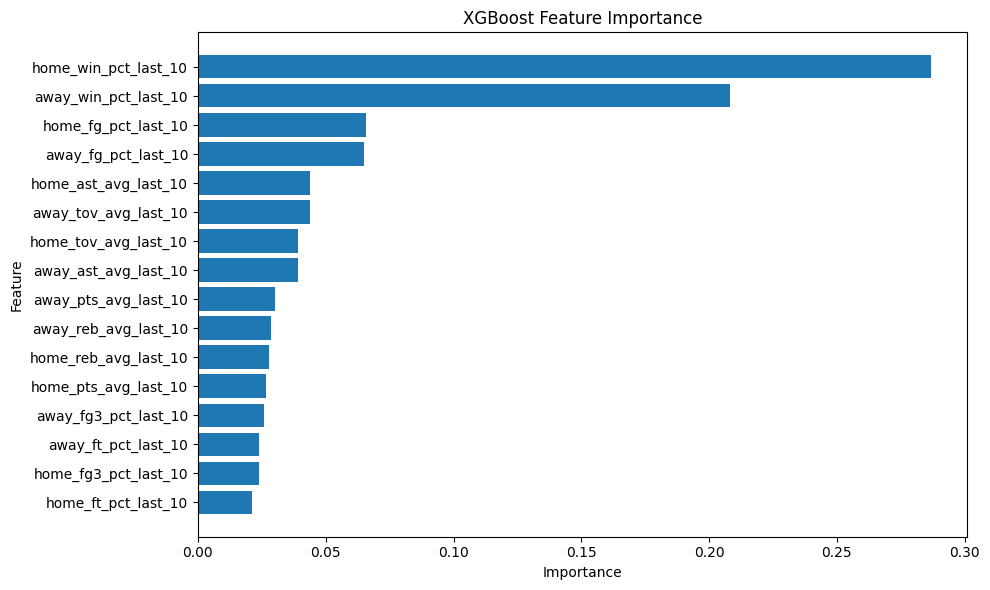

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.gca().invert_yaxis()

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [58]:
# Evaluate different classification thresholds on validation data
threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):
    predictions = (
        xgb_val_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        'Threshold': round(threshold, 2),
        'Accuracy': accuracy_score(y_val, predictions),
        'Away Recall': classification_report(
            y_val,
            predictions,
            output_dict=True,
            zero_division=0
        )['0']['recall'],
        'Home Recall': classification_report(
            y_val,
            predictions,
            output_dict=True,
            zero_division=0
        )['1']['recall']
    })

threshold_results = pd.DataFrame(threshold_results)

print(threshold_results.round(3))

   Threshold  Accuracy  Away Recall  Home Recall
0       0.30     0.571        0.040        0.995
1       0.35     0.580        0.082        0.977
2       0.40     0.590        0.137        0.952
3       0.45     0.610        0.234        0.910
4       0.50     0.629        0.364        0.841
5       0.55     0.633        0.500        0.739
6       0.60     0.614        0.619        0.611
7       0.65     0.596        0.733        0.486
8       0.70     0.560        0.854        0.325


In [59]:
# Use the validation-selected probability threshold
xgb_threshold = 0.55

xgb_val_predictions_055 = (
    xgb_val_probabilities >= xgb_threshold
).astype(int)

print("Classification Report:")
print(
    classification_report(
        y_val,
        xgb_val_predictions_055
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_val,
        xgb_val_predictions_055
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.50      0.55       876
           1       0.65      0.74      0.69      1097

    accuracy                           0.63      1973
   macro avg       0.63      0.62      0.62      1973
weighted avg       0.63      0.63      0.63      1973

Confusion Matrix:
[[438 438]
 [286 811]]


In [60]:
from itertools import product

# Small, controlled set of XGBoost parameters to test
param_grid = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.10],
    'n_estimators': [100, 200, 300]
}

tuning_results = []

for max_depth, learning_rate, n_estimators in product(
    param_grid['max_depth'],
    param_grid['learning_rate'],
    param_grid['n_estimators']
):

    model = XGBClassifier(
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )

    model.fit(X_train, y_train)

    # Validation probabilities
    val_probs = model.predict_proba(X_val)[:, 1]

    # Use our validation-selected 0.55 threshold
    val_preds = (val_probs >= 0.55).astype(int)

    tuning_results.append({
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'n_estimators': n_estimators,
        'accuracy': accuracy_score(y_val, val_preds),
        'roc_auc': roc_auc_score(y_val, val_probs)
    })

tuning_results = pd.DataFrame(tuning_results)

# Show the best-performing combinations
tuning_results.sort_values(
    ['accuracy', 'roc_auc'],
    ascending=False
).head(10)

,max_depth,learning_rate,n_estimators,accuracy,roc_auc
19,4,0.03,200,0.637101,0.667667
12,3,0.05,100,0.636594,0.669003
10,3,0.03,200,0.636594,0.668808
6,2,0.10,100,0.636594,0.664690
9,3,0.03,100,0.635073,0.669447
20,4,0.03,300,0.634567,0.665120
4,2,0.05,200,0.634060,0.666206
11,3,0.03,300,0.633553,0.667361
13,3,0.05,200,0.633046,0.668349
3,2,0.05,100,0.633046,0.666610


In [61]:
# Train the selected XGBoost configuration
final_xgb = XGBClassifier(
    max_depth=4,
    learning_rate=0.03,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

final_xgb.fit(X_train, y_train)

# Generate validation probabilities and predictions
final_xgb_val_probabilities = final_xgb.predict_proba(X_val)[:, 1]

final_xgb_val_predictions = (
    final_xgb_val_probabilities >= 0.55
).astype(int)

print(
    "Validation accuracy:",
    round(
        accuracy_score(y_val, final_xgb_val_predictions),
        3
    )
)

print(
    "Validation ROC-AUC:",
    round(
        roc_auc_score(y_val, final_xgb_val_probabilities),
        3
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        final_xgb_val_predictions
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_val,
        final_xgb_val_predictions
    )
)

Validation accuracy: 0.637
Validation ROC-AUC: 0.668

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.50      0.55       876
           1       0.65      0.75      0.70      1097

    accuracy                           0.64      1973
   macro avg       0.63      0.62      0.62      1973
weighted avg       0.63      0.64      0.63      1973

Confusion Matrix:
[[437 439]
 [277 820]]


## Random Forest

In [63]:
from sklearn.ensemble import RandomForestClassifier

# Train a baseline Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Generate training and validation predictions
rf_train_predictions = rf_model.predict(X_train)
rf_val_predictions = rf_model.predict(X_val)

# Generate validation probabilities
rf_val_probabilities = rf_model.predict_proba(X_val)[:, 1]

print(
    "Training accuracy:",
    round(accuracy_score(y_train, rf_train_predictions), 3)
)

print(
    "Validation accuracy:",
    round(accuracy_score(y_val, rf_val_predictions), 3)
)

print(
    "Validation ROC-AUC:",
    round(roc_auc_score(y_val, rf_val_probabilities), 3)
)

print(
    "Validation baseline:",
    round(val_baseline_accuracy, 3)
)

Training accuracy: 0.729
Validation accuracy: 0.619
Validation ROC-AUC: 0.666
Validation baseline: 0.556


In [64]:
print("Classification Report:")
print(
    classification_report(
        y_val,
        rf_val_predictions
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_val,
        rf_val_predictions
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.29      0.40       876
           1       0.61      0.88      0.72      1097

    accuracy                           0.62      1973
   macro avg       0.64      0.59      0.56      1973
weighted avg       0.63      0.62      0.58      1973

Confusion Matrix:
[[254 622]
 [130 967]]


In [65]:
rf_threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):
    predictions = (
        rf_val_probabilities >= threshold
    ).astype(int)

    report = classification_report(
        y_val,
        predictions,
        output_dict=True,
        zero_division=0
    )

    rf_threshold_results.append({
        'Threshold': round(threshold, 2),
        'Accuracy': accuracy_score(y_val, predictions),
        'Away Recall': report['0']['recall'],
        'Home Recall': report['1']['recall']
    })

rf_threshold_results = pd.DataFrame(rf_threshold_results)

print(rf_threshold_results.round(3))

   Threshold  Accuracy  Away Recall  Home Recall
0       0.30     0.560        0.009        0.999
1       0.35     0.572        0.042        0.995
2       0.40     0.574        0.072        0.975
3       0.45     0.587        0.144        0.942
4       0.50     0.619        0.290        0.881
5       0.55     0.625        0.463        0.755
6       0.60     0.611        0.643        0.586
7       0.65     0.593        0.790        0.436
8       0.70     0.543        0.898        0.260


## Neural Network

In [66]:
from sklearn.neural_network import MLPClassifier

# Build a small feed-forward neural network
nn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=64,
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    ))
])

# Train only on the training period
nn_model.fit(X_train, y_train)

# Generate predictions
nn_train_predictions = nn_model.predict(X_train)
nn_val_predictions = nn_model.predict(X_val)

# Generate validation probabilities
nn_val_probabilities = nn_model.predict_proba(X_val)[:, 1]

print(
    "Training accuracy:",
    round(accuracy_score(y_train, nn_train_predictions), 3)
)

print(
    "Validation accuracy:",
    round(accuracy_score(y_val, nn_val_predictions), 3)
)

print(
    "Validation ROC-AUC:",
    round(roc_auc_score(y_val, nn_val_probabilities), 3)
)

print(
    "Validation baseline:",
    round(val_baseline_accuracy, 3)
)

print(
    "Training iterations:",
    nn_model.named_steps['model'].n_iter_
)

Training accuracy: 0.65
Validation accuracy: 0.632
Validation ROC-AUC: 0.664
Validation baseline: 0.556
Training iterations: 26


In [67]:
print("Classification Report:")
print(
    classification_report(
        y_val,
        nn_val_predictions
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_val,
        nn_val_predictions
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.37      0.47       876
           1       0.63      0.84      0.72      1097

    accuracy                           0.63      1973
   macro avg       0.64      0.61      0.60      1973
weighted avg       0.64      0.63      0.61      1973

Confusion Matrix:
[[327 549]
 [177 920]]


In [68]:
nn_threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):
    predictions = (
        nn_val_probabilities >= threshold
    ).astype(int)

    report = classification_report(
        y_val,
        predictions,
        output_dict=True,
        zero_division=0
    )

    nn_threshold_results.append({
        'Threshold': round(threshold, 2),
        'Accuracy': accuracy_score(y_val, predictions),
        'Away Recall': report['0']['recall'],
        'Home Recall': report['1']['recall']
    })

nn_threshold_results = pd.DataFrame(nn_threshold_results)

print(nn_threshold_results.round(3))

   Threshold  Accuracy  Away Recall  Home Recall
0       0.30     0.578        0.067        0.985
1       0.35     0.586        0.114        0.963
2       0.40     0.600        0.182        0.934
3       0.45     0.616        0.272        0.892
4       0.50     0.632        0.373        0.839
5       0.55     0.629        0.484        0.746
6       0.60     0.628        0.589        0.659
7       0.65     0.607        0.697        0.535
8       0.70     0.576        0.799        0.398


In [69]:
nn_tuning_results = []

architectures = [
    (16,),
    (32,),
    (32, 16),
    (64, 32)
]

alpha_values = [
    0.0001,
    0.001,
    0.01
]

for architecture in architectures:
    for alpha in alpha_values:

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(
                hidden_layer_sizes=architecture,
                activation='relu',
                solver='adam',
                alpha=alpha,
                batch_size=64,
                learning_rate_init=0.001,
                max_iter=500,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=20,
                random_state=42
            ))
        ])

        model.fit(X_train, y_train)

        val_probs = model.predict_proba(X_val)[:, 1]
        val_preds = (val_probs >= 0.50).astype(int)

        nn_tuning_results.append({
            'architecture': str(architecture),
            'alpha': alpha,
            'iterations': model.named_steps['model'].n_iter_,
            'accuracy': accuracy_score(y_val, val_preds),
            'roc_auc': roc_auc_score(y_val, val_probs)
        })

nn_tuning_results = pd.DataFrame(nn_tuning_results)

nn_tuning_results.sort_values(
    ['accuracy', 'roc_auc'],
    ascending=False
)

,architecture,alpha,iterations,accuracy,roc_auc
7,"(32, 16)",0.0010,26,0.632032,0.664358
6,"(32, 16)",0.0001,25,0.625950,0.663572
8,"(32, 16)",0.0100,25,0.621896,0.662532
0,"(16,)",0.0001,58,0.621389,0.662403
5,"(32,)",0.0100,24,0.619868,0.660246
2,"(16,)",0.0100,28,0.618855,0.661274
11,"(64, 32)",0.0100,25,0.618348,0.663146
4,"(32,)",0.0010,24,0.618348,0.660235
10,"(64, 32)",0.0010,25,0.616320,0.660840
3,"(32,)",0.0001,23,0.615813,0.662622


## Model Selection

Four machine learning approaches were evaluated: Logistic Regression, Random Forest, XGBoost, and a feed-forward Neural Network.

The tuned XGBoost model was selected as the final model. It achieved the highest validation accuracy at 63.7%, compared with a 55.6% home-team baseline. Its validation ROC-AUC was 0.668.

A probability threshold of 0.55 was selected using the validation data. This improved the balance between identifying home and away wins while also slightly improving overall validation accuracy.

The final XGBoost configuration uses:
- Maximum tree depth: 4
- Learning rate: 0.03
- Number of estimators: 200
- Classification threshold: 0.55

More complex models did not automatically perform better. The Neural Network achieved 63.2% validation accuracy, while Random Forest showed a larger gap between training and validation performance, suggesting greater overfitting.

The 2021–2023 test period was not used during model selection, threshold selection, or hyperparameter tuning.

In [70]:
# Final evaluation on the untouched 2021-2023 test period

test_probabilities = final_xgb.predict_proba(X_test)[:, 1]

test_predictions = (
    test_probabilities >= 0.55
).astype(int)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

print(
    "Test accuracy:",
    round(test_accuracy, 3)
)

print(
    "Test ROC-AUC:",
    round(test_roc_auc, 3)
)

print(
    "Test baseline:",
    round(test_baseline_accuracy, 3)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_predictions
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        test_predictions
    )
)

Test accuracy: 0.599
Test ROC-AUC: 0.622
Test baseline: 0.56

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.44      0.49      1642
           1       0.62      0.73      0.67      2087

    accuracy                           0.60      3729
   macro avg       0.59      0.58      0.58      3729
weighted avg       0.59      0.60      0.59      3729

Confusion Matrix:
[[ 716  926]
 [ 569 1518]]


## Final Test Results

The selected XGBoost model was evaluated once on the untouched 2021–2023 test period.

Results:
- Test accuracy: 59.9%
- Home-team baseline accuracy: 56.0%
- ROC-AUC: 0.622
- Away-win recall: 44%
- Home-win recall: 73%

The model remained more accurate than the naive home-team baseline, but performance declined compared with the 2019–2020 validation period, where the selected model achieved 63.7% accuracy and a 0.668 ROC-AUC.

This decline suggests that the relationships learned from historical NBA data did not generalize as strongly to the later test period. Rather than retuning the model using the test data, the performance decline is treated as a model-risk finding that requires further investigation.

In [71]:
# Analyze final model performance by year

test_results = test_df[[
    'game_id',
    'game_date',
    'home_win'
]].copy()

test_results['prediction'] = test_predictions
test_results['probability'] = test_probabilities
test_results['year'] = test_results['game_date'].dt.year

yearly_results = []

for year, group in test_results.groupby('year'):

    yearly_results.append({
        'Year': year,
        'Games': len(group),
        'Home Win Rate': group['home_win'].mean(),
        'Model Accuracy': accuracy_score(
            group['home_win'],
            group['prediction']
        ),
        'ROC-AUC': roc_auc_score(
            group['home_win'],
            group['probability']
        )
    })

yearly_results = pd.DataFrame(yearly_results)

print(yearly_results.round(3))

   Year  Games  Home Win Rate  Model Accuracy  ROC-AUC
0  2021   1625          0.546           0.605    0.635
1  2022   1336          0.575           0.603    0.612
2  2023    768          0.561           0.581    0.612


## Performance Over Time

Performance was also evaluated separately for each year of the untouched test period.

| Year | Games | Home Win Rate | Model Accuracy | ROC-AUC |
|------|------:|--------------:|---------------:|--------:|
| 2021 | 1,625 | 54.6% | 60.5% | 0.635 |
| 2022 | 1,336 | 57.5% | 60.3% | 0.612 |
| 2023 | 768 | 56.1% | 58.1% | 0.612 |

The model remained above the home-team baseline during each test year, but its advantage over the baseline decreased over time. ROC-AUC also declined compared with the validation period.

This indicates potential performance drift and shows why model performance should be monitored after deployment rather than relying only on initial validation results.

The results do not by themselves identify the cause of the performance decline. Potential causes would require further investigation, including changes in team behavior, feature distributions, relationships between features and outcomes, and other changes between the training and test periods.

## Model Risk & Validation

### Feature Drift Analysis

Because model performance declined during the out-of-time test period, the
input features were compared across the training, validation, and test periods.

Changes in feature distributions may indicate data drift and can help explain
why a model's performance changes over time.

In [72]:
# Compare average feature values across each time period

drift_summary = pd.DataFrame({
    'Training': X_train.mean(),
    'Validation': X_val.mean(),
    'Test': X_test.mean()
})

drift_summary['Test vs Train % Change'] = (
    (drift_summary['Test'] - drift_summary['Training'])
    / drift_summary['Training'].abs()
) * 100

print(drift_summary.round(3))

                      Training  Validation     Test  Test vs Train % Change
home_win_pct_last_10     0.498       0.496    0.498                   0.007
home_pts_avg_last_10    98.643     111.453  112.122                  13.665
home_fg_pct_last_10      0.452       0.459    0.467                   3.265
home_fg3_pct_last_10     0.353       0.357    0.359                   1.523
home_ft_pct_last_10      0.753       0.772    0.779                   3.402
home_reb_avg_last_10    42.101      44.966   43.953                   4.399
home_ast_avg_last_10    21.705      24.495   24.746                  14.009
home_tov_avg_last_10    14.630      14.189   13.843                  -5.381
away_win_pct_last_10     0.502       0.508    0.505                   0.489
away_pts_avg_last_10    98.740     111.728  112.360                  13.793
away_fg_pct_last_10      0.452       0.460    0.468                   3.378
away_fg3_pct_last_10     0.353       0.357    0.360                   2.070
away_ft_pct_

#### Initial Drift Findings

Several model features changed between the training and test periods.

The largest changes occurred in scoring and assists. Average points increased
by approximately 14%, while average assists also increased by approximately
14%. Turnovers decreased by approximately 5%, and shooting percentages showed
smaller increases.

Recent team win percentage remained relatively stable.

These results provide evidence that the distribution of several model inputs
changed over time. Because model performance also declined during the
out-of-time test period, these changes represent a potential model-risk
concern.

However, changes in feature averages alone do not establish that feature drift
caused the decline in model performance. Additional distribution-level testing
is needed.

In [73]:
from scipy.stats import ks_2samp

drift_tests = []

for feature in feature_columns:

    ks_stat, p_value = ks_2samp(
        X_train[feature],
        X_test[feature]
    )

    drift_tests.append({
        'Feature': feature,
        'KS Statistic': ks_stat,
        'P-Value': p_value
    })

drift_tests = pd.DataFrame(drift_tests)

drift_tests = drift_tests.sort_values(
    'KS Statistic',
    ascending=False
).reset_index(drop=True)

print(drift_tests.round(4))

                 Feature  KS Statistic  P-Value
0   away_pts_avg_last_10        0.7169   0.0000
1   home_pts_avg_last_10        0.7156   0.0000
2   home_ast_avg_last_10        0.4819   0.0000
3   away_ast_avg_last_10        0.4816   0.0000
4   home_reb_avg_last_10        0.2678   0.0000
5    away_fg_pct_last_10        0.2676   0.0000
6   away_reb_avg_last_10        0.2582   0.0000
7    home_fg_pct_last_10        0.2575   0.0000
8    home_ft_pct_last_10        0.2367   0.0000
9    away_ft_pct_last_10        0.2355   0.0000
10  away_tov_avg_last_10        0.1855   0.0000
11  home_tov_avg_last_10        0.1822   0.0000
12  away_fg3_pct_last_10        0.1171   0.0000
13  home_fg3_pct_last_10        0.1038   0.0000
14  away_win_pct_last_10        0.0320   0.0022
15  home_win_pct_last_10        0.0271   0.0155


#### Distribution Drift Findings

A Kolmogorov-Smirnov (KS) test was used to compare each feature's training
distribution with its distribution during the 2021–2023 test period.

The strongest distribution shifts occurred in recent scoring and assists.
Home and away points-per-game features produced KS statistics above 0.71,
while assist features produced KS statistics near 0.48.

Recent win-percentage features were considerably more stable, with KS
statistics below 0.04.

These results confirm that several model inputs changed substantially between
the training and test periods. This creates model risk because relationships
learned from historical data may not remain equally representative of newer
NBA games.

The feature drift occurred alongside a decline in out-of-time model
performance. However, the analysis does not establish that feature drift
directly caused the performance decline.

## Probability Calibration

Classification accuracy measures whether the predicted winner was correct,
but it does not measure whether predicted probabilities are reliable.

Calibration analysis compares predicted win probabilities with observed
outcomes to determine whether the model is overconfident or underconfident.

In [76]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# Get validation and test probabilities
val_probabilities = final_xgb.predict_proba(X_val)[:, 1]
test_probabilities = final_xgb.predict_proba(X_test)[:, 1]

# Brier score: lower is better
val_brier = brier_score_loss(y_val, val_probabilities)
test_brier = brier_score_loss(y_test, test_probabilities)

print("Validation Brier Score:", round(val_brier, 4))
print("Test Brier Score:", round(test_brier, 4))

# Create calibration bins
val_fraction_positive, val_mean_predicted = calibration_curve(
    y_val,
    val_probabilities,
    n_bins=10,
    strategy='uniform'
)

test_fraction_positive, test_mean_predicted = calibration_curve(
    y_test,
    test_probabilities,
    n_bins=10,
    strategy='uniform'
)

calibration_results = pd.DataFrame({
    'Validation Predicted': pd.Series(val_mean_predicted),
    'Validation Actual': pd.Series(val_fraction_positive),
    'Test Predicted': pd.Series(test_mean_predicted),
    'Test Actual': pd.Series(test_fraction_positive)
})

print("\nCalibration Results:")
print(calibration_results.round(3))

Validation Brier Score: 0.2279
Test Brier Score: 0.2383

Calibration Results:
   Validation Predicted  Validation Actual  Test Predicted  Test Actual
0                 0.159              0.000           0.191        0.000
1                 0.273              0.194           0.268        0.289
2                 0.358              0.341           0.359        0.366
3                 0.459              0.364           0.456        0.439
4                 0.550              0.520           0.551        0.526
5                 0.651              0.615           0.651        0.587
6                 0.745              0.695           0.744        0.676
7                 0.832              0.817           0.834        0.733
8                 0.910              0.833           0.912        1.000


#### Calibration Findings

The model's probability calibration weakened on the out-of-time test period.

The Brier score increased from 0.2279 during validation to 0.2383 during testing. Because lower Brier scores indicate better probability estimates, this suggests that the model's predicted probabilities became less reliable on newer data.

Calibration was relatively close in several middle-probability ranges.
However, the model became increasingly overconfident at higher predicted
home-win probabilities. For example, games with an average predicted
probability of approximately 83% resulted in home wins approximately 73% of
the time.

This creates another model-risk concern. A model can still have reasonable accuracy while its predicted probabilities become less reliable. Because of this, both model performance and probability calibration should be monitored.

Extreme probability bins should be interpreted cautiously because they may
contain relatively few observations.

### Error Analysis

Error analysis examines where the final model makes incorrect predictions.
Particular attention is given to the balance between home and away prediction
errors and to incorrect predictions made with high confidence.

High-confidence errors are important from a model-risk perspective because
they indicate situations where the model is strongly confident despite
producing an incorrect prediction.

In [78]:
# Build a test-results dataset for error analysis
error_analysis = test_df[[
    'game_id',
    'game_date',
    'team_name_home',
    'team_name_away',
    'home_win'
]].copy()

error_analysis['prediction'] = test_predictions
error_analysis['home_win_probability'] = test_probabilities

# Confidence in whichever outcome the model predicted
error_analysis['confidence'] = np.where(
    error_analysis['prediction'] == 1,
    error_analysis['home_win_probability'],
    1 - error_analysis['home_win_probability']
)

error_analysis['correct'] = (
    error_analysis['prediction'] == error_analysis['home_win']
)

print("Total test games:", len(error_analysis))
print("Correct predictions:", error_analysis['correct'].sum())
print("Incorrect predictions:", (~error_analysis['correct']).sum())

print(
    "\nAccuracy when predicting home win:",
    round(
        error_analysis.loc[
            error_analysis['prediction'] == 1,
            'correct'
        ].mean(),
        3
    )
)

print(
    "Accuracy when predicting away win:",
    round(
        error_analysis.loc[
            error_analysis['prediction'] == 0,
            'correct'
        ].mean(),
        3
    )
)

Total test games: 3729
Correct predictions: 2234
Incorrect predictions: 1495

Accuracy when predicting home win: 0.621
Accuracy when predicting away win: 0.557


In [79]:
# Incorrect predictions made with at least 70% confidence
high_confidence_errors = error_analysis[
    (~error_analysis['correct']) &
    (error_analysis['confidence'] >= 0.70)
].copy()

print(
    "High-confidence errors:",
    len(high_confidence_errors)
)

print(
    "Percent of all test games:",
    round(
        len(high_confidence_errors) /
        len(error_analysis) * 100,
        2
    ),
    "%"
)

print(
    "Percent of all model errors:",
    round(
        len(high_confidence_errors) /
        (~error_analysis['correct']).sum() * 100,
        2
    ),
    "%"
)

high_confidence_errors.sort_values(
    'confidence',
    ascending=False
).head(10)

High-confidence errors: 307
Percent of all test games: 8.23 %
Percent of all model errors: 20.54 %


,game_id,game_date,team_name_home,team_name_away,home_win,prediction,home_win_probability,confidence,correct
32647,22100875,2022-02-16,Boston Celtics,Detroit Pistons,0,1,0.898059,0.898059,False
33353,22200258,2022-11-22,Denver Nuggets,Detroit Pistons,0,1,0.887296,0.887296,False
32742,22100966,2022-03-06,LA Clippers,New York Knicks,0,1,0.886106,0.886106,False
31529,22000927,2021-04-27,Boston Celtics,Oklahoma City Thunder,0,1,0.885538,0.885538,False
34261,22201166,2023-04-02,Minnesota Timberwolves,Portland Trail Blazers,0,1,0.878783,0.878783,False
32609,22100837,2022-02-10,Golden State Warriors,New York Knicks,0,1,0.876125,0.876125,False
32401,22100632,2022-01-14,Charlotte Hornets,Orlando Magic,0,1,0.875838,0.875838,False
30996,22000405,2021-02-12,Sacramento Kings,Orlando Magic,0,1,0.860800,0.860800,False
31393,22000800,2021-04-10,Brooklyn Nets,Los Angeles Lakers,0,1,0.859692,0.859692,False
31308,22000720,2021-03-30,LA Clippers,Orlando Magic,0,1,0.859386,0.859386,False


#### Error Analysis Findings

The final model correctly predicted 2,234 of 3,729 test games and incorrectly
predicted 1,495.

Predictions favoring the home team were more reliable than predictions
favoring the away team. The model was correct on 62.1% of predicted home wins
compared with 55.7% of predicted away wins.

High-confidence errors were also examined. The model made 307 incorrect
predictions with at least 70% confidence. These represented 8.23% of all test
games and 20.54% of all model errors.

Several incorrect predictions occurred even when the model assigned the
predicted winner probabilities above 85%. These results reinforce the
calibration findings and demonstrate that high model confidence does not
guarantee a correct prediction.

From a model-risk perspective, confidence scores should therefore be monitored
alongside realized outcomes, and highly confident predictions should not be
treated as certain.

### Model Risk Register

The following risks were identified during development and validation of the
NBA game prediction model.

| Risk | Evidence | Severity | Mitigation |
|---|---|---|---|
| Data Leakage | The original model used statistics from the same game it was attempting to predict, producing misleading performance near 85% accuracy. | High | Rebuilt the feature pipeline using only historical information available before each game and applied shift(1) before rolling calculations. |
| Performance Drift | Validation accuracy was 63.7%, while out-of-time test accuracy declined to 59.9%. ROC-AUC declined from 0.668 to 0.622. | High | Monitor accuracy, ROC-AUC, recall, and baseline performance over time. Investigate significant deterioration before continued model use. |
| Feature Drift | Several input distributions changed substantially. Home and away scoring features produced KS statistics above 0.71 between training and test data. | High | Monitor feature distributions and establish drift thresholds that trigger investigation or model review. |
| Probability Calibration | Brier score worsened from 0.2279 during validation to 0.2383 during testing, with overconfidence visible at higher predicted probabilities. | Medium | Monitor Brier score and calibration over time and consider probability recalibration when necessary. |
| High-Confidence Errors | 307 test predictions were incorrect despite model confidence of at least 70%, representing 20.54% of all model errors. | Medium | Track high-confidence errors and avoid treating probability estimates as certainty. |
| Class Performance Imbalance | The model was correct on 62.1% of predicted home wins compared with 55.7% of predicted away wins. | Medium | Monitor class-specific precision, recall, and error rates rather than relying only on overall accuracy. |
| Overfitting | Random Forest achieved 72.9% training accuracy but only 61.9% validation accuracy. | Medium | Use chronological validation, compare training and validation performance, and prefer models that generalize better. |
| Historical Representativeness | Training data spans 1995–2018 while the NBA environment changed substantially over time. | High | Periodically retrain using newer representative data and reevaluate the appropriate historical training window. |

### Model Monitoring Plan

If the model were deployed, performance and data quality would be monitored
regularly to identify deterioration before predictions became unreliable.

| Area | Metric | Monitoring Frequency | Warning Trigger | Response |
|---|---|---|---|---|
| Predictive Performance | Accuracy | Monthly | Accuracy falls below the home-team baseline or declines materially from validated performance | Investigate recent predictions, data quality, and potential model drift |
| Ranking Performance | ROC-AUC | Monthly | ROC-AUC falls below 0.60 or shows sustained deterioration | Review feature relationships and consider model retraining |
| Feature Drift | KS Statistic | Monthly | Major features show substantial distribution changes compared with the training reference | Investigate data changes and determine whether training data remains representative |
| Calibration | Brier Score and calibration curve | Monthly | Brier score materially worsens or predicted probabilities become consistently overconfident | Review probability reliability and consider recalibration |
| Class Performance | Precision and Recall | Monthly | Large deterioration in home- or away-win performance | Investigate class-specific errors and prediction threshold |
| High-Confidence Errors | Incorrect predictions with confidence >= 70% | Monthly | Sustained increase in high-confidence error rate | Review calibration, feature drift, and recent incorrect predictions |
| Data Quality | Missing values, duplicates, invalid outcomes | Each data refresh | Unexpected missing values, duplicate games, or invalid records | Stop scoring until the data issue is investigated and corrected |

#### Monitoring Response Process

If one of the monitoring metrics starts showing a problem, the model would
need to be reviewed before deciding what to do next.

1. Check the data and pipeline first to make sure there is not an error.
2. Look at recent performance to see if the problem is temporary or continuing
   over time.
3. Check for feature drift, calibration problems, or changes in the types of
   errors the model is making.
4. Document what changed and how much it is affecting the model.
5. If performance continues to decline, retrain or recalibrate the model using
   newer data.
6. Test the updated model on data that was not used for training.
7. If the model still does not perform well enough, it should not continue
   being used until the problem is addressed.

## 10. Model Card & Final Validation Summary

### Model Overview

This project predicts whether the home team will win an NBA game using
information that would have been available before the game started.

The project is also a rebuild of an earlier version of the model. During the
review of the original project, I found that it used statistics from the game
being predicted. This created data leakage and made the original accuracy of
about 85% misleading.

For this version, I rebuilt the data pipeline so that every feature is based
only on information from games that happened before the game being predicted.

### Data and Features

The original dataset contained 65,698 NBA games. Because several statistics
had large amounts of missing data in older seasons, I limited the modeling
period to games from 1995 onward and used regular-season and playoff games.

After cleaning the data and creating the historical features, the final
modeling dataset contained 34,410 games.

Each team's features were calculated using its previous 10 games. The model
uses recent information such as:

- Win percentage
- Average points
- Field goal percentage
- Three-point percentage
- Free throw percentage
- Rebounds
- Assists
- Turnovers

The rolling features were shifted by one game so that the current game's
results could not be included in its own prediction.

### Model Development

The data was split by time instead of using a random train/test split.

- Training: 1995–2018
- Validation: 2019–2020
- Test: 2021–2023

I compared Logistic Regression, Random Forest, XGBoost, and a Neural Network.

XGBoost was selected as the final model because it had the best validation
accuracy while still generalizing better than the other models. The final
classification threshold was 0.55.

The test period was kept separate while the models and threshold were being
selected.

### Final Results

The final XGBoost model achieved:

- Validation accuracy: 63.7%
- Validation ROC-AUC: 0.668
- Test accuracy: 59.9%
- Test ROC-AUC: 0.622
- Test home-team baseline: 56.0%

The model beat the simple home-team baseline on the full test set and in each
individual test year. However, performance declined from the validation period
to the test period.

Instead of changing the model after seeing the test results, I treated the
performance decline as something that needed to be investigated.

### Validation Findings

The validation process found several important risks and limitations.

**Feature Drift**

Several features changed between the training and test periods. The largest
changes were in scoring and assists. The KS statistics for home and away
scoring were above 0.71, showing a large difference between their training and
test distributions.

**Probability Calibration**

The Brier score increased from 0.2279 during validation to 0.2383 during
testing. The model also showed signs of being overconfident when predicting
higher probabilities of a home win.

**Prediction Errors**

The model was more accurate when predicting home wins than away wins. It was
correct on 62.1% of predicted home wins compared with 55.7% of predicted away
wins.

There were also 307 incorrect predictions where the model was at least 70%
confident. These made up 20.54% of all model errors.

Together, these results show why model accuracy by itself is not enough to
decide whether a model is reliable.

### Limitations

There are several limitations to this model.

The model only uses historical team performance and does not include other
information that could affect a game, such as injuries, starting lineups,
player availability, rest days, travel, roster changes, or betting-market
information.

The 10-game rolling features also continue across season boundaries. This
means a team's first few games of a new season can still include games from
the previous season even though the roster or coaching staff may have changed.

The training period covers many years of NBA history, and the feature drift
analysis showed that the way the game is played has changed over time.

The validation period was also used for both model tuning and threshold
selection. A more advanced version of the project could use multiple
time-based validation periods instead.

Because of these limitations, the model should be treated as an analytical
project rather than a system for making guaranteed predictions or betting
decisions.

### Final Validation Decision

The model shows that historical team performance contains useful information
for predicting NBA game outcomes. It performed better than the home-team
baseline on the untouched test data, but the decline in accuracy, ROC-AUC,
and probability calibration shows that its performance is not completely
stable over time.

If this model were being used in a real system, I would allow it to continue
only with regular monitoring. Accuracy, ROC-AUC, calibration, feature drift,
class-specific performance, and high-confidence errors should all be tracked.

A large or continuing decline in these metrics would trigger a review before
the model was retrained or updated.

The biggest lesson from this project was that a model with a higher accuracy
is not automatically a better model. The original version appeared to perform
much better, but that performance was partly caused by data leakage. The
rebuilt version has lower accuracy, but its evaluation is much more realistic
and its risks and limitations are documented.